In [1]:
%pip install pymysql pandas

Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


正在連線到 bda2026 資料庫...

--- 正在撈取 華城 (1519) 的每日股價資料 ---


C:\Users\a3504\AppData\Local\Temp\ipykernel_4556\4290686364.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_prices = pd.read_sql(query_prices, conn)


>> 正在顯示股價走勢圖，請查看彈出視窗 (看完關閉後繼續印出財報)...


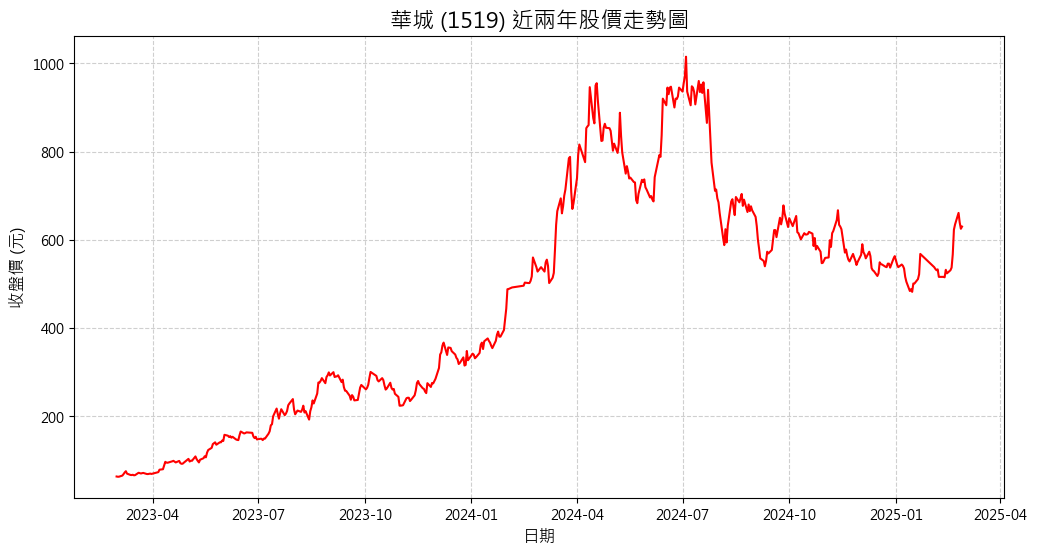


--- 正在撈取與處理損益表資料 ---

=== 華城 (1519) 財報處理結果 ===
     年份  季別  累計營收(億)  單季營收(億)  累計營業利益(億)  單季營業利益(億)  累計淨利(億)  單季淨利(億)  累計EPS  單季EPS
0  2023   1    15.41    15.41       2.22       2.22     2.03     2.03   0.79   0.79
1  2023   2    46.43    31.03       8.14       5.92     7.42     5.39   2.87   2.08
2  2023   3    82.88    36.44      15.90       7.77    14.52     7.10   5.60   2.73
3  2023   4   139.00    56.12      28.54      12.63    25.62    11.10   9.87   4.27
4  2024   1    30.38    30.38       6.21       6.21     5.94     5.94   2.29   2.29
5  2024   2    76.83    46.46      17.71      11.50    14.84     8.90   5.20   2.91
6  2024   3   130.40    53.57      31.87      14.16    27.10    12.27   9.48   4.28
7  2024   4   202.03    71.63      48.91      17.04    42.71    15.61  14.93   5.45

資料庫連線已關閉。


C:\Users\a3504\AppData\Local\Temp\ipykernel_4556\4290686364.py:61: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_income = pd.read_sql(query_income, conn)


: 

In [ ]:
import pymysql
import pandas as pd
import matplotlib.pyplot as plt

# 設定 Matplotlib 支援中文顯示 (Windows 預設為微軟正黑體，Mac 為 Arial Unicode MS)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False # 讓負號能正常顯示

print("正在連線到 bda2026 資料庫...")
conn = pymysql.connect(
    host='127.0.0.1',
    port=3306,
    user='root',
    password='',
    database='bda2026',
    charset='utf8mb4'
)

try:
    target_id = '1519' # 已經確認是華城
    target_name = '華城'

    # ==========================================
    # 1. 股價資料提取與繪製曲線
    # ==========================================
    print(f"\n--- 正在撈取 {target_name} ({target_id}) 的每日股價資料 ---")
    query_prices = f"""
        SELECT trade_date, closing_price 
        FROM stock_prices 
        WHERE company_id = '{target_id}' 
        ORDER BY trade_date;
    """
    df_prices = pd.read_sql(query_prices, conn)
    
    # 確保 trade_date 是 datetime 格式，方便畫時間軸
    df_prices['trade_date'] = pd.to_datetime(df_prices['trade_date'])
    
    # 繪製股價折線圖
    plt.figure(figsize=(12, 6)) # 設定圖表大小
    plt.plot(df_prices['trade_date'], df_prices['closing_price'], color='red', linewidth=1.5)
    plt.title(f"{target_name} (1519) 近兩年股價走勢圖", fontsize=16)
    plt.xlabel("日期", fontsize=12)
    plt.ylabel("收盤價 (元)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # 顯示圖表 (執行時會彈出一個視窗，關閉視窗後程式才會繼續往下跑)
    print(">> 正在顯示股價走勢圖，請查看彈出視窗 (看完關閉後繼續印出財報)...")
    plt.show() 


    # ==========================================
    # 2. 財報資料提取與數據清理 (累計 vs 單季)
    # ==========================================
    print("\n--- 正在撈取與處理損益表資料 ---")
    query_income = f"""
        SELECT fiscal_year, fiscal_quarter, revenue, operating_income, net_income, eps 
        FROM income_stmt 
        WHERE company_id = '{target_id}' 
        ORDER BY fiscal_year, fiscal_quarter;
    """
    df_income = pd.read_sql(query_income, conn)
    
    # 計算單季數據 (當季減去前一季)
    cols_to_diff = ['revenue', 'operating_income', 'net_income', 'eps']
    for col in cols_to_diff:
        # groupby 確保不會拿 2024年的 Q1 去減 2023年的 Q4
        df_income[f'{col}_single'] = df_income.groupby('fiscal_year')[col].diff().fillna(df_income[col])
    
    # 單位換算：將原本的「千元」換算為「億元」 (除以 100,000)
    # EPS 單位不變，只做四捨五入
    cols_to_scale = ['revenue', 'operating_income', 'net_income', 
                     'revenue_single', 'operating_income_single', 'net_income_single']
    
    for col in cols_to_scale:
        df_income[col] = (df_income[col] / 100000).round(2)
        
    df_income['eps'] = df_income['eps'].round(2)
    df_income['eps_single'] = df_income['eps_single'].round(2)

    # 重新排列並挑選需要的欄位，讓單季與累計並排比較
    df_income_final = df_income[[
        'fiscal_year', 'fiscal_quarter',
        'revenue', 'revenue_single',
        'operating_income', 'operating_income_single',
        'net_income', 'net_income_single',
        'eps', 'eps_single'
    ]]
    
    # 重新命名為好讀的中文欄位
    df_income_final.columns = [
        '年份', '季別', 
        '累計營收(億)', '單季營收(億)', 
        '累計營業利益(億)', '單季營業利益(億)', 
        '累計淨利(億)', '單季淨利(億)', 
        '累計EPS', '單季EPS'
    ]

    print("\n=== 華城 (1519) 財報處理結果 ===")
    # pd.set_option 讓 dataframe 印出來的時候不會因為太長被折疊
    pd.set_option('display.max_columns', None) 
    pd.set_option('display.width', 1000)
    print(df_income_final)

finally:
    conn.close()
    print("\n資料庫連線已關閉。")